## Black-hole binary formation channels with gaussian mixtures.


Many problems in astrophysics give rise to data with multiple modes. This is typically because different processes physical processes contribute to the observed dataset. 

For instance, one of the most outstanding question in gravitational-wave astrophysics is the formation channel of binary black holes. Leading scenarions include the evolution of isolated binaries in the galactic field and the dynamica assembly of sources in dense environments like globular clusters.


Right now, state-of-the-art analyses seems to say that many channels are all at play where they consider 5 possibilities for the formation of black hole binaries: common envelope (CE), chemically omogenous stars (CHE), globular clusters (GC), nuclear star clusters (NSC) and stable mass transfer (SMT). 

If you want to know more about LIGO-driven astrophysics and black hole binaries formation channels, these are some recent reviews: [Mandel and Farmer (2021)](https://arxiv.org/abs/1806.05820), [Mapelli (2021)](https://arxiv.org/abs/2106.00699), [Gerosa and Fishbach (2021)](https://arxiv.org/abs/2105.03439).

Anyway. You can find today's dataset at `solutions/formationchannels.npy`.

*Hint*: Note that the data provided are of shape (N,1), not (N,). This might be confusing at first, but it's the format that sklearn wants (more on this in a future lecture).  A useful tool to convert between the two is [np.newaxis](https://stackoverflow.com/questions/29241056/how-does-numpy-newaxis-work-and-when-to-use-it).

-----------------------------------------------------------------------------------------------------------------------------------------------------------

Some events form in different astrophysical environments than others. **You want to figure out how many of formation channels are at play.**


The strategy here is to fit a Gaussian Mixture model: that is, my model is a sum of $N$ gaussians each with mean $\mu_j$ and standard deviation $\sigma_j$ and weight $\alpha_j$:

$p(x_i|\theta) = \sum_{j=1}^N \alpha_j \mathcal{N}(\mu_j,\sigma_j) $

This depends on $3N-1$ parameters (not $3N$ because the sum of the $\alpha_j$ must be unity to ensure that this is a probability.

#### Tasks

1) Load this file (`np.load`) and complete a quick exploration of the data. How many modes do you think you see?

2) We'll use `sklearn.mixture.GaussianMixture`. You first need to define the model (instance of a class), and then train it on the data using the `fit` method (the data provided are already in the right numpy format!). This will output the trained model, which has various attributes.

*Note*. We'll do a more formal introduction to scikit-learn in one of the next lectures. Today's exercise is meant to be a formative example on how you might find yourself dealing with a library you've never seen before. This happens *all the time* in research...

3) Complete the fit 10 times with $N=1,...,10$ Gaussians. 

Note: `sklearn` by default will use the so-called [Expectation-Maximization algorithm](https://en.wikipedia.org/wiki/Expectation%E2%80%93maximization_algorithm), which is one of the many great things in data science we don't have time to study in this class.

4) For each of this fits, compute the AIC (easy! It's an attribute of the trained model!). Plot $N$ vs AIC: which model is preferred?

5) Plot the preferred solution on top of the input data. You should get a very nice fit!

In [1]:
#Iniziamo importando le solite librerie
from matplotlib import pyplot as plt
import numpy as np
from sklearn.mixture import GaussianMixture
random_state = np.random.RandomState(seed=1)
import os

In [2]:
#Carichiamo i dati presi dalla cartella ./solutions
X = np.load("formationchannels.npy")

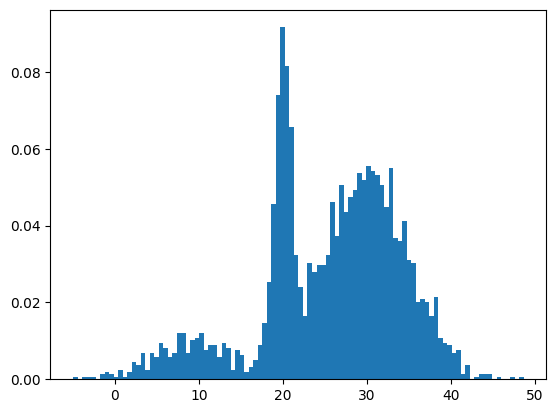

In [3]:
#Facciamo un rapido check con un istogramma per vedere come sono fatti
plt.hist(X, bins = 100, density = True);

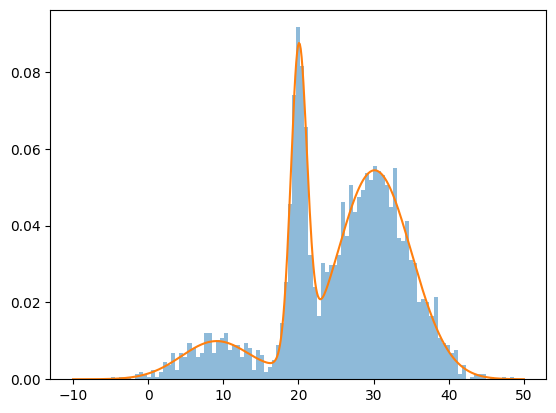

In [8]:
#Proviamo ad usare sklearn.mixture.GaussianMixture per il modello che sottendiamo, ovvero il modello a 3N-1 parametri di 
#N modi di gaussiana combinati linearmente e pesati
#https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html

model = GaussianMixture(n_components = 3).fit(X)

#proviamo a farne una sovrapposizione

x = np.linspace(-10, 50, 500)
#scikit si aspetta sempre (N,1) quindi devo aggiungere un asse all'asse x per calcolarci sopra con model
x_scikit = x[:, np.newaxis]
plt.hist(X, bins = 100, alpha = 0.5, density = True);
plt.plot(x, np.exp(model.score_samples(x_scikit))) #a quanto pare la funzione GMM ha solo l'attributo .score_samples(x) 
                                                   # Compute the log-likelihood of each sample."  dunque faccio l'exp per ottenere la pdf


#Con tre funziona piuttosto bene ma facciamolo con una mixture fino a 10 gaussiane.
plt.savefig("./Images/EX_5_Bestfit.png")

plt.show()


[ 1  2  3  4  5  6  7  8  9 10]
[GaussianMixture(n_components=np.int64(1)), GaussianMixture(n_components=np.int64(2)), GaussianMixture(n_components=np.int64(3)), GaussianMixture(n_components=np.int64(4)), GaussianMixture(n_components=np.int64(5)), GaussianMixture(n_components=np.int64(6)), GaussianMixture(n_components=np.int64(7)), GaussianMixture(n_components=np.int64(8)), GaussianMixture(n_components=np.int64(9)), GaussianMixture(n_components=np.int64(10))]


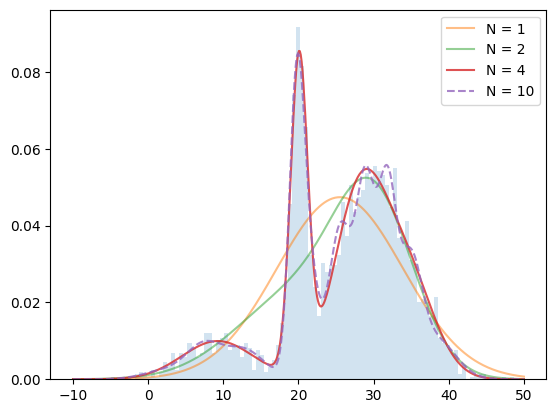

In [5]:
N = np.arange(1,11, dtype = int) #lo stop non è incluso dunque per avere N = 10 metto 11
print(N)
models = [GaussianMixture(n_components = n).fit(X) for n in N]

print(models)
plt.hist(X, bins = 100, alpha = 0.2, density = True);
for n in N:
    if(n == 1 or n == 2 or n == 4 or n == 10): plt.plot(x, np.exp(models[n-1].score_samples(x_scikit)), label = f"N = {n}", linestyle = "-" if n <= 4 else "--",
                                                       alpha = 0.5 if n < 4 else 0.8)
plt.legend()
plt.savefig("./Images/EX_5_Fits_Comparison.png")
plt.show()

[20945.9726085902, 20754.077242280502, 20083.175884272052, 20101.69537047714, 20112.988655264075, 20122.27777037135, 20129.281958803625, 20137.716424045426, 20140.191673650545, 20152.617064629776]


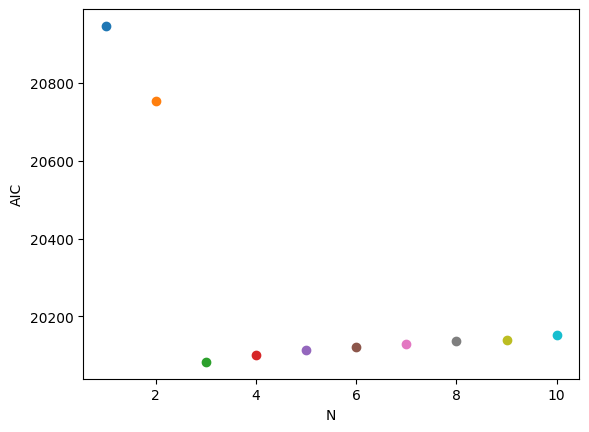

In [6]:
#Ora computiamo l'AIC (Akaike Information Criterion) The model with lowest AIC is the most favored
aic = [models[n-1].aic(X) for n in N]
print(aic)
for n in N:
    plt.scatter(n, aic[n-1])
plt.savefig("./Images/EX_5_AIC.png")
plt.ylabel('AIC')
plt.xlabel('N')
plt.show()
#Emerge che a N = 3 ho l'AIC minore.

#### [Optional tasks, not examinable] Class labels or "responsibilities"

Class labels are a very interesting by product of a mixture analysis. What is the probability that a given gravitational-wave event comes from a given channel? This is called "responsiblity" (i.e. which mode is most likely to be responsible for that piece of data). 

$p(j|x_i) = \frac{a_j \mathcal{N(\mu_j,\sigma_j)}}{\sum_{j=1}^N \alpha_j \mathcal{N}(\mu_j,\sigma_j)}$

6) [**Optional**] Understand (i.e. plot) which Gaussian mode corresponds to which part of the input dataset. 

*Hint:* Useful methods here are `score_samples` and `predict_proba`.


7) [**Optional**] Derive the expression above using Bayes' rule (pen and paper!)

Per quanto riguarda l'espressione di p(j|xi) ho che dal teorema di Bayes
$p(j|x_i) = \frac{p(x_i|j) \cdot p(j)}{p(x_i)} = \frac{p(x_i|j) p(j)}{\sum_i p(x_i|j) p(j)}$. 

In questo caso p(j) è $a_j$ ovvero il peso della gaussiana legata al canale j-esimo nel gaussian-mixture da cui che

$p(j|x_i) = \frac{a_j \mathcal{N(\mu_j,\sigma_j)}}{\sum_{j=1}^N \alpha_j \mathcal{N}(\mu_j,\sigma_j)}$


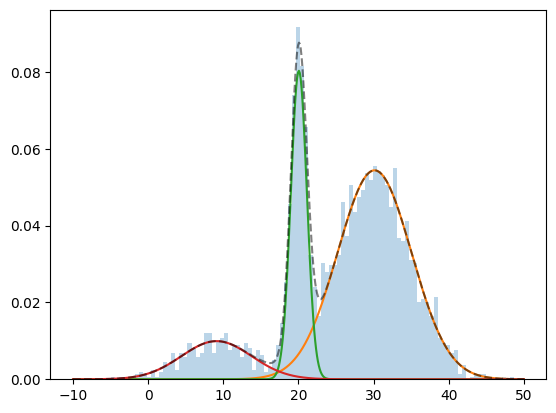

In [7]:
#Accediamo alle "responsibilities" con predict_proba "Evaluate the components’ density for each sample.". Usiamo il fit a N = 3
resps =  model.predict_proba(x_scikit)
pdf =np.exp(model.score_samples(x_scikit))
pdf_single = resps * pdf[:,np.newaxis]

plt.hist(X, 100, density=True, alpha = 0.3);
plt.plot(x, pdf_single[:,0])
plt.plot(x, pdf_single[:,1])
plt.plot(x, pdf_single[:,2])
plt.plot(x, pdf, linestyle="--", c = 'black', alpha = 0.5)
plt.savefig("./Images/EX_5_Single_Channels.png")